In [1]:
import pandas as pd #tables / data
import yfinance as yf #historical data 
import matplotlib.pyplot as plt #plotting data
import numpy as np #numerical operations

In [78]:
#Constraints and set variables
bound_start = "2010-01-01"
bound_end = "2026-09-01" 
set_interval = "1d"
default_auto_adjust = False

Tickers = ["SPY", "QQQ", "IWM", "DIA", "MDY", "EFA",
           "EEM", "VWO", "VNQ", "XLF", "XLK", "XLE",
           "XLV", "XLI", "XLP","XLY", "XLU", "XLB", "TLT", 
           "IEF", "SHY", "AGG", "LQD", "HYG", "TIP",
           "GLD", "SLV", "DBC", "USO", "GSG"]

#extract data:
data = yf.download(Tickers, start = bound_start, end = bound_end,  interval = set_interval, 
                   auto_adjust = default_auto_adjust)

#offsets:
num_offset = 21
denum_offset = 252


[*********************100%***********************]  30 of 30 completed


In [79]:
#Checks for the data:
data.index.is_monotonic_increasing
data.isna().sum()
data.index.has_duplicates
(data.index.dayofweek >=5).any()

np.False_

In [80]:
#Pull out adj close
adj_close_data = data["Adj Close"]

##Calculate momentum scores at 2020-12-31
formation_date = "2020-12-31"
formation_idx = adj_close_data.index.get_loc(formation_date)

momentum_scores = (adj_close_data.iloc[formation_idx- num_offset]/adj_close_data.iloc[formation_idx - denum_offset])-1
momentum_scores = momentum_scores.sort_values(ascending=False)
top_6 = momentum_scores[:6]
print(top_6)

Ticker
QQQ    0.409306
XLK    0.352808
SLV    0.326591
XLY    0.260024
XLB    0.202448
GLD    0.182216
dtype: float64


([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'QQQ'),
  Text(1, 0, 'XLK'),
  Text(2, 0, 'SLV'),
  Text(3, 0, 'XLY'),
  Text(4, 0, 'XLB'),
  Text(5, 0, 'GLD')])

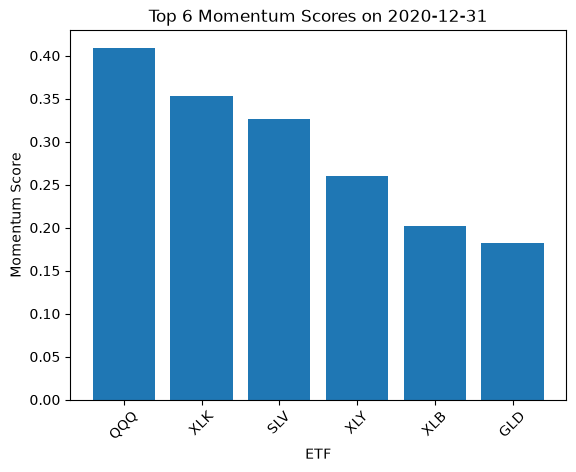

In [81]:
plt.bar(top_6.index, top_6)
plt.title("Top 6 Momentum Scores on 2020-12-31")
plt.xlabel("ETF")
plt.ylabel("Momentum Score")
plt.xticks(rotation=45)

In [82]:
#Why exclude approximately the most recent month in a 12-1 signal?
##The strategy is intended to capture intermediate term omentum rather than 
##short term price movements which may be noiser -> news shocks, trading noise etc

#How is a 12-1 signal different from a simple trailing 12-month return?
##trailing 12 month return uses the current price in the numerator

#Why should ranking be cross-sectional - comparing assets on the same date - rather than comparing raw score levels across different dates?
##You want to compare them on a relative basis

#What could go wrong if one ETF has missing history and you rank it anyway?
##You literally cannot calculate the momentum lol
